In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
# Loading the dataset and displaying the first few rows and column names
data = pd.read_csv('walmartds.csv')
print(data.head())
print(data.columns)

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')


In [40]:
#1
# Converting Date column into datetime format
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
# Setting Date as the index of the DataFrame
data.set_index('Date', inplace=True)

In [41]:
#2
# Resampling data from daily to monthly format
monthly_data = data['Weekly_Sales'].resample('ME').sum()
monthly_data = monthly_data.to_frame()

In [42]:
#3
# Computing moving averages 
monthly_data['Moving_Average'] = monthly_data['Weekly_Sales'].rolling(window=3).mean()

In [43]:
#4
# Calculating rolling mean
monthly_data['Rolling_Mean'] = monthly_data['Weekly_Sales'].rolling(window=3).mean()
# Calculating rolling standard deviation
monthly_data['Rolling_Std'] = monthly_data['Weekly_Sales'].rolling(window=3).std()

In [44]:
# Removing all the missing values from the DataFrame
monthly_data = monthly_data.dropna()

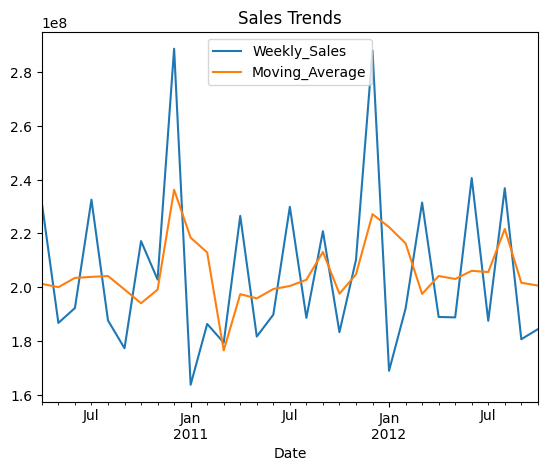

In [50]:
#5
# Analyzing the trends and seasonality patterns in the data
monthly_data[['Weekly_Sales', 'Moving_Average']].plot()
plt.title("Sales Trends")
plt.show()

In [51]:
print(monthly_data.head())

            Weekly_Sales  Moving_Average  Rolling_Mean   Rolling_Std
Date                                                                
2010-04-30  2.314124e+08    2.012217e+08  2.012217e+08  2.648211e+07
2010-05-31  1.867109e+08    2.000144e+08  2.000144e+08  2.729679e+07
2010-06-30  1.922462e+08    2.034565e+08  2.034565e+08  2.436818e+07
2010-07-31  2.325801e+08    2.038457e+08  2.038457e+08  2.503814e+07
2010-08-31  1.876401e+08    2.041555e+08  2.041555e+08  2.472397e+07
